In [11]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

In [12]:
#Load Data
df = pd.read_csv("../data/processed/sentiment_results_v2.csv")
ihsg = pd.read_csv("../data/ihsg/ihsg_data.csv")

df["date"] = pd.to_datetime(df["date"])
ihsg["date"] = pd.to_datetime(ihsg["date"])

print(f"News: {len(df)} articles")
print(f"IHSG: {len(ihsg)} trading days")
print(f"\nNews date range: {df['date'].min()} → {df['date'].max()}")
print(f"IHSG date range: {ihsg['date'].min()} → {ihsg['date'].max()}")

News: 10068 articles
IHSG: 390 trading days

News date range: 2024-10-01 00:00:00 → 2026-06-01 00:00:00
IHSG date range: 2024-10-01 00:00:00 → 2026-05-29 00:00:00


In [13]:
#Aggregate Daily Sentiment
# Convert sentiment to numeric score
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sentiment_num"] = df["sentiment"].map(sentiment_map)

# Daily aggregation
daily = df.groupby("date").agg(
    sentiment_mean=("sentiment_num", "mean"),
    positive_count=("sentiment", lambda x: (x == "positive").sum()),
    negative_count=("sentiment", lambda x: (x == "negative").sum()),
    neutral_count=("sentiment", lambda x: (x == "neutral").sum()),
    total_articles=("title", "count")
).reset_index()

print(f"Daily sentiment shape: {daily.shape}")
print(daily.head(10))

Daily sentiment shape: (582, 6)
        date  sentiment_mean  positive_count  negative_count  neutral_count  \
0 2024-10-01             0.0               0               0              2   
1 2024-10-02             0.0               0               0              2   
2 2024-10-03             0.0               0               0              1   
3 2024-10-08             0.0               0               0              7   
4 2024-10-09            -0.5               0               1              1   
5 2024-10-10             0.0               0               0              4   
6 2024-10-11             0.0               0               0              3   
7 2024-10-12             0.0               0               0              5   
8 2024-10-13             0.0               0               0              1   
9 2024-10-14             0.0               0               0              3   

   total_articles  
0               2  
1               2  
2               1  
3               7 

In [14]:
#Merge Sentiment with IHSG
merged = pd.merge(daily, ihsg, on="date", how="inner")
print(f"Merged shape: {merged.shape}")
print(f"Date range: {merged['date'].min()} → {merged['date'].max()}")
print(merged.head(5))

Merged shape: (381, 7)
Date range: 2024-10-01 00:00:00 → 2026-05-29 00:00:00
        date  sentiment_mean  positive_count  negative_count  neutral_count  \
0 2024-10-01             0.0               0               0              2   
1 2024-10-02             0.0               0               0              2   
2 2024-10-03             0.0               0               0              1   
3 2024-10-08             0.0               0               0              7   
4 2024-10-09            -0.5               0               1              1   

   total_articles        close  
0               2  7642.132812  
1               2  7563.262207  
2               1  7543.828125  
3               7  7557.142090  
4               2  7501.285156  


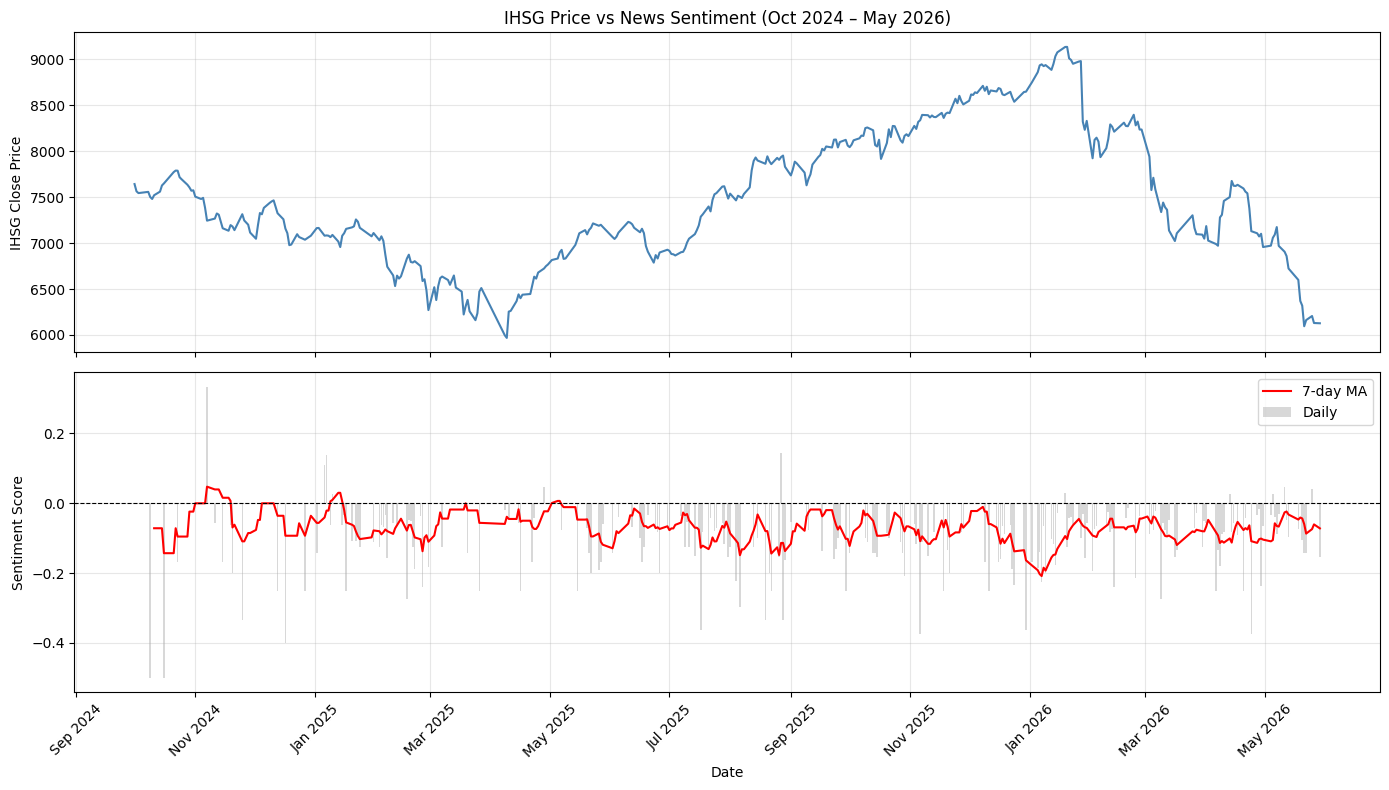

In [15]:
#Plot Sentiment vs IHSG
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot IHSG
ax1.plot(merged["date"], merged["close"], color="steelblue", linewidth=1.5)
ax1.set_ylabel("IHSG Close Price")
ax1.set_title("IHSG Price vs News Sentiment (Oct 2024 – May 2026)")
ax1.grid(alpha=0.3)

# Plot sentiment (7-day rolling average)
rolling_sentiment = merged["sentiment_mean"].rolling(7).mean()
ax2.bar(merged["date"], merged["sentiment_mean"], color="gray", alpha=0.3, label="Daily")
ax2.plot(merged["date"], rolling_sentiment, color="red", linewidth=1.5, label="7-day MA")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Sentiment Score")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_vs_ihsg.png", dpi=150, bbox_inches="tight")
plt.show()

Pearson Correlation: -0.1195
P-value: 0.0196
Significant: Yes


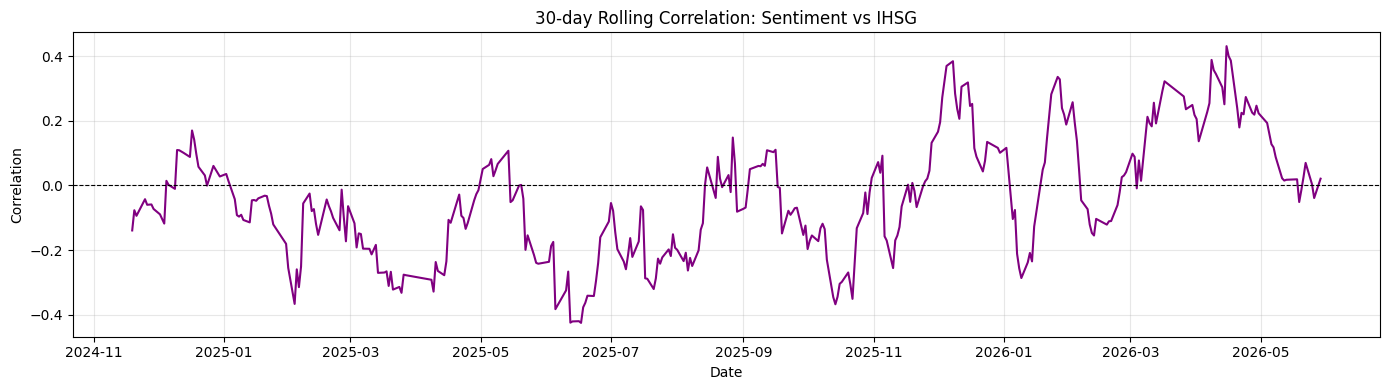

In [16]:
#Correlation Analysis

# Pearson correlation
corr, pvalue = stats.pearsonr(merged["sentiment_mean"], merged["close"])
print(f"Pearson Correlation: {corr:.4f}")
print(f"P-value: {pvalue:.4f}")
print(f"Significant: {'Yes' if pvalue < 0.05 else 'No'}")

# Rolling correlation (30-day)
merged["rolling_corr"] = merged["sentiment_mean"].rolling(30).corr(merged["close"])

plt.figure(figsize=(14, 4))
plt.plot(merged["date"], merged["rolling_corr"], color="purple", linewidth=1.5)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("30-day Rolling Correlation: Sentiment vs IHSG")
plt.ylabel("Correlation")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
#Lagged Correlation

print("=== Lagged Correlation ===")
for lag in [1, 2, 3, 5, 7]:
    merged[f"sentiment_lag{lag}"] = merged["sentiment_mean"].shift(lag)
    temp = merged.dropna(subset=[f"sentiment_lag{lag}"])
    corr_lag, pval_lag = stats.pearsonr(temp[f"sentiment_lag{lag}"], temp["close"])
    sig = "Significant" if pval_lag < 0.05 else "Not significant"
    print(f"Lag {lag} days: r={corr_lag:.4f}, p={pval_lag:.4f} ({sig})")

=== Lagged Correlation ===
Lag 1 days: r=-0.1310, p=0.0106 (Significant)
Lag 2 days: r=-0.1205, p=0.0189 (Significant)
Lag 3 days: r=-0.1178, p=0.0220 (Significant)
Lag 5 days: r=-0.1389, p=0.0070 (Significant)
Lag 7 days: r=-0.1545, p=0.0027 (Significant)


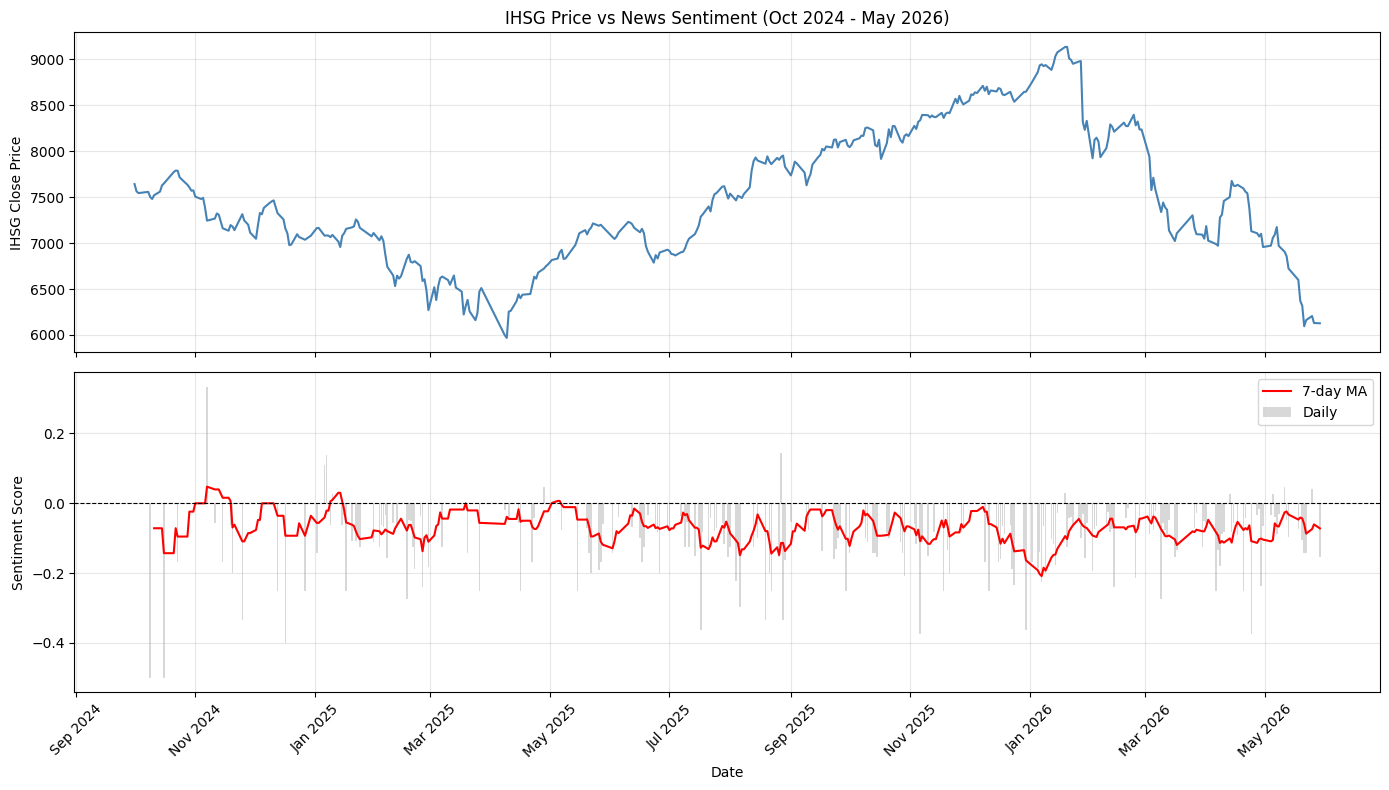

Saved


In [18]:
#Plot Sentiment vs IHSG
import os
os.makedirs("../outputs/figures", exist_ok=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(merged["date"], merged["close"], color="steelblue", linewidth=1.5)
ax1.set_ylabel("IHSG Close Price")
ax1.set_title("IHSG Price vs News Sentiment (Oct 2024 - May 2026)")
ax1.grid(alpha=0.3)

rolling_sentiment = merged["sentiment_mean"].rolling(7).mean()
ax2.bar(merged["date"], merged["sentiment_mean"], color="gray", alpha=0.3, label="Daily")
ax2.plot(merged["date"], rolling_sentiment, color="red", linewidth=1.5, label="7-day MA")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Sentiment Score")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_vs_ihsg.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

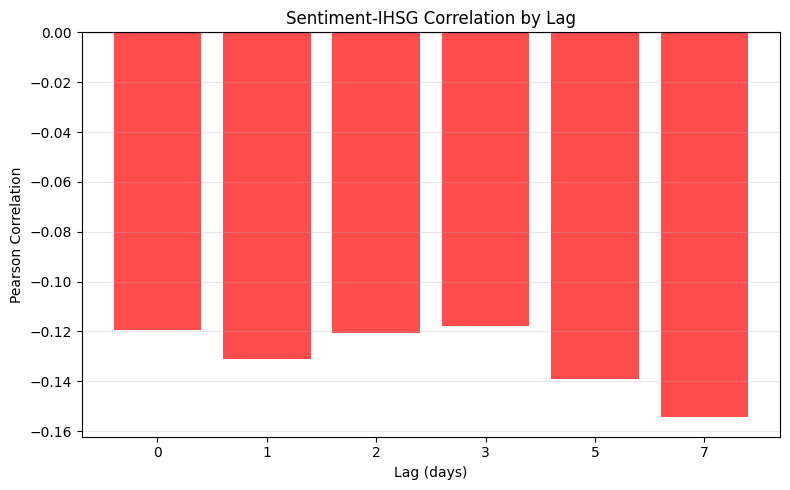

Saved


In [19]:
#Lag Correlation Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))

lags = [0, 1, 2, 3, 5, 7]
corrs = [-0.1195, -0.1310, -0.1205, -0.1178, -0.1389, -0.1545]

colors = ["red" if c < 0 else "green" for c in corrs]
ax.bar([str(l) for l in lags], corrs, color=colors, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Sentiment-IHSG Correlation by Lag")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../outputs/figures/lag_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

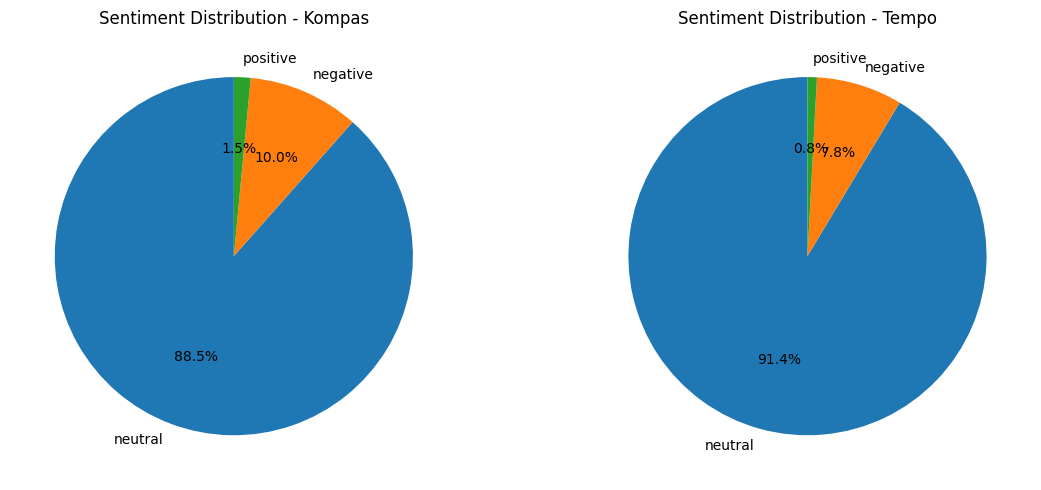

Saved


In [20]:
#Sentiment per Source
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, source in enumerate(["Kompas", "Tempo"]):
    subset = df[df["source"] == source]["sentiment"].value_counts()
    axes[idx].pie(subset, labels=subset.index, autopct="%1.1f%%", startangle=90)
    axes[idx].set_title(f"Sentiment Distribution - {source}")

plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_by_source.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

In [21]:
#Top Negative & Positive Days
print("=== Top 5 Most Negative Days ===")
top_neg = merged.nsmallest(5, "sentiment_mean")[["date", "sentiment_mean", "negative_count", "close"]]
print(top_neg.to_string())

print("\n=== Top 5 Most Positive Days ===")
top_pos = merged.nlargest(5, "sentiment_mean")[["date", "sentiment_mean", "positive_count", "close"]]
print(top_pos.to_string())

=== Top 5 Most Negative Days ===
          date  sentiment_mean  negative_count        close
4   2024-10-09          -0.500               1  7501.285156
9   2024-10-16          -0.500               1  7648.939941
46  2024-12-17          -0.400               2  7157.731934
252 2025-11-06          -0.375               3  8337.057617
360 2026-04-24          -0.375               3  7129.490234

=== Top 5 Most Positive Days ===
          date  sentiment_mean  positive_count        close
23  2024-11-07        0.333333               1  7243.859863
202 2025-08-27        0.142857               1  7936.175781
57  2025-01-07        0.137931               6  7083.284180
56  2025-01-06        0.108696               9  7080.474121
124 2025-04-28        0.047619               1  6722.965820


In [24]:
#Most negative & positive news
print("=== Most Negative Day Articles (2024-10-09) ===")
neg_day = df[df["date"] == "2024-10-09"].sort_values("sentiment_score")
print(neg_day[["title", "sentiment", "sentiment_score", "source"]].to_string())

print("\n=== Most Positive Day Articles (2025-01-07) ===")
pos_day = df[df["date"] == "2025-01-07"].sort_values("sentiment_score", ascending=False)
print(pos_day[["title", "sentiment", "sentiment_score", "source"]].to_string())

=== Most Negative Day Articles (2024-10-09) ===
                                                                       title sentiment  sentiment_score source
7666  Usulan Gaji Pekerja Dipotong untuk Kredit Rumah. Seperti Apa Skemanya?  negative        -0.960756  Tempo
4728                             Prabowo Terbitkan Perpres Gaji Hakim Ad Hoc   neutral        -0.000579  Tempo

=== Most Positive Day Articles (2025-01-07) ===
                                                                                                              title sentiment  sentiment_score source
10020                                 Makan Bergizi Gratis di Dua PAUD di Jakarta: Satu Tepat Waktu, Satu Terlambat  positive         0.949687  Tempo
10027           Cerita Pengusaha Katering Sediakan Makan Bergizi Gratis: Di Jawa Tempe Itu Protein, Medan Mana Bisa  positive         0.715994  Tempo
9936                        Makan Bergizi Gratis: Dari Usul Penggunaan Dana Zakat hingga Jepang akan Beri Pelatihan  pos

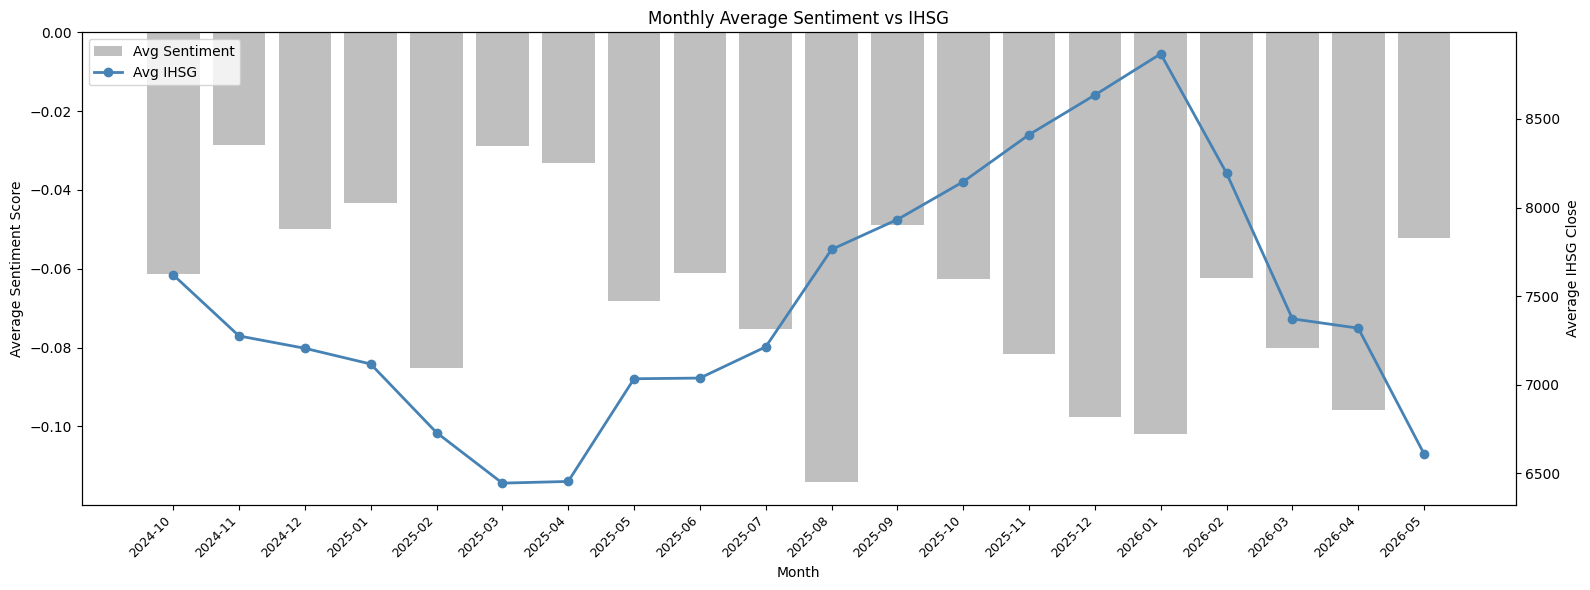

Saved


In [23]:
#Monthly Trend
merged["month"] = merged["date"].dt.to_period("M")
monthly = merged.groupby("month").agg(
    sentiment_mean=("sentiment_mean", "mean"),
    close_mean=("close", "mean")
).reset_index()
monthly["month"] = monthly["month"].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(monthly["month"], monthly["sentiment_mean"], color="gray", alpha=0.5, label="Avg Sentiment")
ax2.plot(monthly["month"], monthly["close_mean"], color="steelblue", linewidth=2, marker="o", label="Avg IHSG")

ax1.set_ylabel("Average Sentiment Score")
ax2.set_ylabel("Average IHSG Close")
ax1.set_xlabel("Month")
ax1.set_title("Monthly Average Sentiment vs IHSG")
ax1.set_xticks(range(len(monthly["month"])))
ax1.set_xticklabels(monthly["month"], rotation=45, ha="right", fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("../outputs/figures/monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

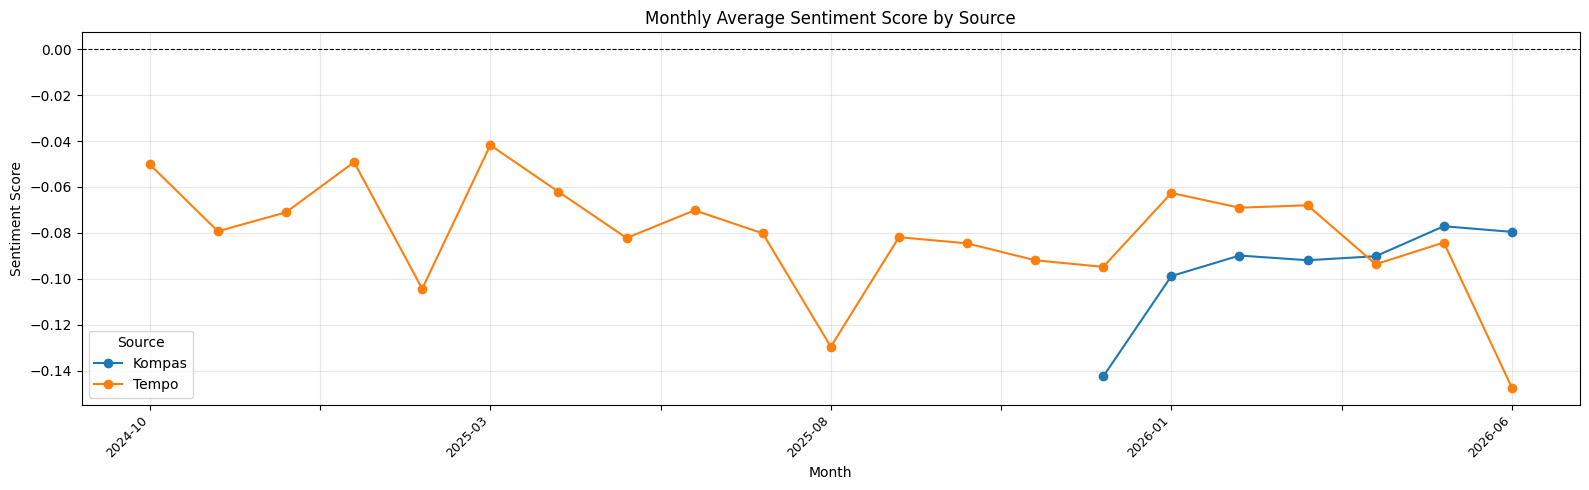

Saved


In [26]:
#Sentiment by Source over Time
monthly_source = df.copy()
monthly_source["month"] = monthly_source["date"].dt.to_period("M").astype(str)

pivot = monthly_source.groupby(["month", "source"])["sentiment_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 5))
pivot.plot(ax=ax, marker="o", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Monthly Average Sentiment Score by Source")
ax.set_ylabel("Sentiment Score")
ax.set_xlabel("Month")
plt.xticks(rotation=45, ha="right", fontsize=9)
ax.legend(title="Source")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_by_source_monthly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")